In [2]:
import lightkurve as lk
import shutil
import os

# ── Save directory ───────────────────────────────────────────────────────
base_dir = "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits"
os.makedirs(base_dir, exist_ok=True)

# ── 5 M-dwarf targets ────────────────────────────────────────────────────
targets = [
    {"name": "LHS 3844",   "sector": 1},   # Huang et al. 2019 — her own paper!
    {"name": "TOI-1130",  "sector": 13},   # Most famous M-dwarf system
    {"name": "L 98-59",    "sector": 2},   # 3 rocky planets
    {"name": "TOI-700",    "sector": 1},   # Habitable zone planet
    {"name": "GJ 1132",    "sector": 1},   # JWST atmosphere target
]

# ── Download and save each one ───────────────────────────────────────────
for target in targets:
    print(f"\n{'='*55}")
    print(f"Searching: {target['name']} — Sector {target['sector']}")
    print(f"{'='*55}")

    try:
        # Search for QLP light curve
        search = lk.search_lightcurve(
            target["name"],
            mission="TESS",
            author="QLP",
            sector=target["sector"]
        )

        if len(search) == 0:
            print(f"⚠️  No QLP data found for {target['name']} in Sector {target['sector']}")
            print("    Trying any available sector...")
            search = lk.search_lightcurve(
                target["name"],
                mission="TESS",
                author="QLP"
            )
            if len(search) == 0:
                print(f"❌  No TESS QLP data found for {target['name']}")
                continue
            print(f"    Found in: {search.table['mission'][0]}")

        # Download
        lc = search[0].download()
        fits_path = lc.filename
        print(f"✅  Downloaded: {fits_path}")

        # Create star folder
        star_dir = os.path.join(base_dir, target["name"].replace(" ", "_"))
        os.makedirs(star_dir, exist_ok=True)

        # Copy FITS file
        filename = os.path.basename(fits_path)
        destination = os.path.join(star_dir, filename)
        shutil.copy2(fits_path, destination)

        print(f"✅  Saved to: {destination}")

    except Exception as e:
        print(f"❌  Error for {target['name']}: {e}")

print(f"\n{'='*55}")
print("✅  All downloads complete!")
print(f"📁  Files saved in: {base_dir}")


Searching: LHS 3844 — Sector 1
✅  Downloaded: /Users/lingaprakash/.lightkurve/cache/mastDownload/HLSP/hlsp_qlp_tess_ffi_s0001-0000000410153553_tess_v01_llc/hlsp_qlp_tess_ffi_s0001-0000000410153553_tess_v01_llc.fits
✅  Saved to: /Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/LHS_3844/hlsp_qlp_tess_ffi_s0001-0000000410153553_tess_v01_llc.fits

Searching: TOI-1130 — Sector 13
✅  Downloaded: /Users/lingaprakash/.lightkurve/cache/mastDownload/HLSP/hlsp_qlp_tess_ffi_s0013-0000000254113311_tess_v01_llc/hlsp_qlp_tess_ffi_s0013-0000000254113311_tess_v01_llc.fits
✅  Saved to: /Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/TOI-1130/hlsp_qlp_tess_ffi_s0013-0000000254113311_tess_v01_llc.fits

Searching: L 98-59 — Sector 2
✅  Downloaded: /Users/lingaprakash/.lightkurve/cache/mastDownload/HLSP/hlsp_qlp_tess_ffi_s0002-0000000307210830_tess_v01_llc/hlsp_qlp_tess_ffi_s0002-0000000307210830_tess_v01_llc.fits
✅  Saved to: /Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/L_98-59/hlsp_qlp_tess_ffi_s

In [4]:
from astropy.io import fits
import numpy as np
import pandas as pd
import os

# ── All 5 star FITS file paths ───────────────────────────────────────────
stars = [
    {
        "name"     : "LHS 3844",
        "fits_path": "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/LHS_3844/hlsp_qlp_tess_ffi_s0001-0000000410153553_tess_v01_llc.fits"
    },
    {
        "name"     : "TOI-1130",
        "fits_path": "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/TOI-1130/hlsp_qlp_tess_ffi_s0013-0000000254113016_tess_v01_llc.fits"
    },
    {
        "name"     : "L 98-59",
        "fits_path": "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/L_98-59/hlsp_qlp_tess_ffi_s0002-0000000307210830_tess_v01_llc.fits"
    },
    {
        "name"     : "TOI-700",
        "fits_path": "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/TOI-700/hlsp_qlp_tess_ffi_s0001-0000000150428135_tess_v01_llc.fits"
    },
    {
        "name"     : "GJ 1132",
        "fits_path": "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/GJ_1132/hlsp_qlp_tess_ffi_s0001-0000000088385780_tess_v01_llc.fits"
    },
]

# ── Helper function — fixes big-endian error ─────────────────────────────
def read_col(data, col_name):
    """Read FITS column and convert byte order for pandas compatibility"""
    arr = data[col_name]
    # Fix big-endian/little-endian mismatch
    return arr.byteswap().newbyteorder()

# ── Store all dataframes ─────────────────────────────────────────────────
all_data = {}

# ── Loop through all stars ───────────────────────────────────────────────
for star in stars:
    name      = star["name"]
    fits_path = star["fits_path"]

    print("=" * 60)
    print(f"STAR: {name}")
    print("=" * 60)

    # Check file exists
    if not os.path.exists(fits_path):
        print(f"❌ File not found: {fits_path}")
        print("   Run the filename checker code to get exact path")
        continue

    # Open FITS
    hdul   = fits.open(fits_path)
    header = hdul[0].header
    data   = hdul[1].data

    # ── Header info ──────────────────────────────────────────────────────
    print(f"Object      : {header.get('OBJECT',  'N/A')}")
    print(f"Star ID     : TIC {header.get('TICID', 'N/A')}")
    print(f"Sector      : {header.get('SECTOR',  'N/A')}")
    print(f"TESS mag    : {header.get('TESSMAG', 'N/A')}")
    print(f"Temperature : {header.get('TEFF',    'N/A')} K")
    print(f"Star mass   : {header.get('MASS',    'N/A')} solar masses")
    print(f"RA          : {header.get('RA_OBJ',  'N/A')} deg")
    print(f"Dec         : {header.get('DEC_OBJ', 'N/A')} deg")

    # ── Read columns — with byte order fix ───────────────────────────────
    df = pd.DataFrame({
        'TIME'           : read_col(data, 'TIME'),
        'SAP_FLUX'       : read_col(data, 'SAP_FLUX'),
        'KSPSAP_FLUX'    : read_col(data, 'KSPSAP_FLUX'),
        'KSPSAP_FLUX_ERR': read_col(data, 'KSPSAP_FLUX_ERR'),
        'QUALITY'        : read_col(data, 'QUALITY'),
        'SAP_BKG'        : read_col(data, 'SAP_BKG'),
        'SAP_X'          : read_col(data, 'SAP_X'),
        'SAP_Y'          : read_col(data, 'SAP_Y'),
    })

    # ── Filter good quality points ────────────────────────────────────────
    good    = (df['QUALITY'] == 0) & np.isfinite(df['SAP_FLUX']) & np.isfinite(df['KSPSAP_FLUX'])
    df_good = df[good].copy()

    # ── Convert to ppm ────────────────────────────────────────────────────
    sap_median         = np.nanmedian(df_good['SAP_FLUX'])
    ksp_median         = np.nanmedian(df_good['KSPSAP_FLUX'])
    df_good['RAW_PPM'] = (df_good['SAP_FLUX']    / sap_median - 1) * 1e6
    df_good['DET_PPM'] = (df_good['KSPSAP_FLUX'] / ksp_median - 1) * 1e6

    # ── Basic statistics ──────────────────────────────────────────────────
    print(f"\nTotal points         : {len(df)}")
    print(f"Good quality points  : {len(df_good)} / {len(df)}")
    print(f"NaN points           : {df['SAP_FLUX'].isna().sum()}")
    print(f"Time start (TBJD)    : {df_good['TIME'].min():.4f}")
    print(f"Time end   (TBJD)    : {df_good['TIME'].max():.4f}")
    print(f"Duration             : {df_good['TIME'].max() - df_good['TIME'].min():.2f} days")
    print(f"Cadence              : {(df_good['TIME'].max()-df_good['TIME'].min())/len(df_good)*24*60:.1f} minutes")
    print(f"SAP_FLUX median      : {sap_median:.1f} e-/s")
    print(f"Raw flux range (ppm) : {df_good['RAW_PPM'].min():.0f}  to  {df_good['RAW_PPM'].max():.0f}")
    print(f"Det flux range (ppm) : {df_good['DET_PPM'].min():.0f}  to  {df_good['DET_PPM'].max():.0f}")

    # ── Save for plotting later ───────────────────────────────────────────
    all_data[name] = df_good

    hdul.close()
    print(f"\n✅ {name} read successfully!")

# ── Final summary table ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"✅ All done! Stars loaded: {len(all_data)}")
print("=" * 60)
print(f"\n{'Star':<12} {'Points':>8} {'Duration(days)':>15} {'Det min(ppm)':>13} {'Det max(ppm)':>13}")
print("-" * 65)
for name, df in all_data.items():
    duration = df['TIME'].max() - df['TIME'].min()
    print(f"{name:<12} {len(df):>8} {duration:>15.2f} {df['DET_PPM'].min():>13.0f} {df['DET_PPM'].max():>13.0f}")

STAR: LHS 3844
Object      : TIC 410153553
Star ID     : TIC 410153553
Sector      : 1
TESS mag    : 11.877
Temperature : 3043.0 K
Star mass   : 0.146 solar masses
RA          : 340.4921 deg
Dec         : -69.169 deg

Total points         : 1281
Good quality points  : 1062 / 1281
NaN points           : 0
Time start (TBJD)    : 1325.3894
Time end   (TBJD)    : 1353.0974
Duration             : 27.71 days
Cadence              : 37.6 minutes
SAP_FLUX median      : 1.0 e-/s
Raw flux range (ppm) : -6259  to  7034
Det flux range (ppm) : -5059  to  7361

✅ LHS 3844 read successfully!
STAR: TOI-1130
❌ File not found: /Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/TOI-1130/hlsp_qlp_tess_ffi_s0013-0000000254113016_tess_v01_llc.fits
   Run the filename checker code to get exact path
STAR: L 98-59
Object      : TIC 307210830
Star ID     : TIC 307210830
Sector      : 2
TESS mag    : 9.393
Temperature : 3469.0 K
Star mass   : 0.311 solar masses
RA          : 124.5319 deg
Dec         : -68.313 deg


In [ ]:
from astropy.io import fits
from astropy.timeseries import BoxLeastSquares
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import os
import warnings
warnings.filterwarnings('ignore')

# ── Install TLS if not already installed ────────────────────
# !pip install transitleastsquares
from transitleastsquares import transitleastsquares, cleaned_array

# ============================================================
# STAR LIST
# ============================================================
stars = [
    {
        "name"          : "LHS 3844",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/LHS_3844/hlsp_qlp_tess_ffi_s0001-0000000410153553_tess_v01_llc.fits",
        "transit_center": 1325.55,    # TBJD — known transit time
        "period"        : 0.4629,     # days — known orbital period
        "duration"      : 0.027,      # days — known transit duration
    },
    {
        "name"          : "TOI-1130",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/TOI-1130/hlsp_qlp_tess_ffi_s0013-0000000254113016_tess_v01_llc.fits",
        "transit_center": 1680.00,
        "period"        : 8.3500,
        "duration"      : 0.120,
    },
    {
        "name"          : "L 98-59",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/L_98-59/hlsp_qlp_tess_ffi_s0002-0000000307210830_tess_v01_llc.fits",
        "transit_center": 1355.70,
        "period"        : 3.6907,
        "duration"      : 0.040,
    },
    {
        "name"          : "TOI-700",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/TOI-700/hlsp_qlp_tess_ffi_s0001-0000000150428135_tess_v01_llc.fits",
        "transit_center": 1327.90,
        "period"        : 37.4240,
        "duration"      : 0.130,
    },
    {
        "name"          : "GJ 1132",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/GJ_1132/hlsp_qlp_tess_ffi_s0001-0000000088385780_tess_v01_llc.fits",
        "transit_center": 1327.30,
        "period"        : 1.6289,
        "duration"      : 0.025,
    },
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def read_col(data, col_name):
    """Fix big-endian FITS byte order for Mac"""
    return data[col_name].byteswap().newbyteorder()


def spline_detrend(time, flux, transit_center, period, duration):
    """
    Basis spline detrending — exactly like Huang et al. 2018
    Steps:
      1. Mask transit points and 3-sigma outliers
      2. Fit spline with knots every 0.3 days
      3. Divide raw flux by spline
    """
    # Step 1a — mask transit points
    transit_mask = np.zeros(len(time), dtype=bool)
    for n in range(-10, 20):
        tc = transit_center + n * period
        transit_mask |= np.abs(time - tc) < (duration / 2 + 0.05)

    # Step 1b — mask 3-sigma outliers
    med = np.nanmedian(flux)
    std = np.nanstd(flux)
    outlier_mask = np.abs(flux - med) > 3 * std

    # Combined exclusion mask
    exclude = transit_mask | outlier_mask | ~np.isfinite(flux)

    # Step 2 — fit spline to clean points only
    time_clean = time[~exclude]
    flux_clean = flux[~exclude]
    sort_idx   = np.argsort(time_clean)
    time_clean = time_clean[sort_idx]
    flux_clean = flux_clean[sort_idx]

    spline     = UnivariateSpline(
        time_clean, flux_clean,
        s=len(time_clean) * 500,   # smoothing factor
        k=3                         # cubic spline
    )
    spline_fit = spline(time)

    # Step 3 — subtract spline (in ppm space)
    flux_detrended = flux - spline_fit

    return flux_detrended, spline_fit


def bls_search(time, flux_norm, period_min=0.3, period_max=30):
    """
    BLS period search — Box Least Squares
    Finds the best-fit box-shaped periodic dip
    """
    # BLS needs normalised flux around 1.0
    flux_norm_bls = 1.0 + flux_norm / 1e6

    bls    = BoxLeastSquares(time, flux_norm_bls)
    result = bls.autopower(
        0.02,                          # minimum transit duration (days)
        minimum_period=period_min,
        maximum_period=period_max,
        frequency_factor=1.0
    )
    best_idx    = np.argmax(result.power)
    best_period = result.period[best_idx]
    best_power  = result.power[best_idx]

    return result, best_period, best_power


def tls_search(time, flux_norm):
    """
    TLS period search — Transit Least Squares
    Uses realistic transit shape (more sensitive than BLS)
    """
    # TLS needs flux normalised around 1.0
    flux_norm_tls         = 1.0 + flux_norm / 1e6
    time_c, flux_c        = cleaned_array(time, flux_norm_tls)

    model  = transitleastsquares(time_c, flux_c)
    result = model.power(
        minimum_period=0.3,
        maximum_period=30,
        show_progress_bar=False
    )
    return result


def false_positive_check(time, flux_ppm, best_period, best_t0, duration_days):
    """
    False positive validation — 3 checks:
      1. No secondary eclipse at phase 0.5
      2. No alternating transit depths (odd vs even)
      3. Transit depth consistent across epochs
    """
    results = {}

    # Phase fold
    phase = (time - best_t0 + best_period/2) % best_period - best_period/2

    # ── Check 1: Secondary eclipse ────────────────────────────────────────
    sec_mask  = np.abs(phase - best_period/2) < duration_days
    pri_mask  = np.abs(phase) < duration_days
    sec_depth = np.nanmedian(flux_ppm[sec_mask]) if sec_mask.sum() > 3 else 0
    pri_depth = np.nanmedian(flux_ppm[pri_mask]) if pri_mask.sum() > 3 else 0

    results['secondary_eclipse_depth'] = sec_depth
    results['primary_depth']           = pri_depth
    results['secondary_check']         = "PASS ✓" if abs(sec_depth) < abs(pri_depth) * 0.3 else "FAIL ✗"

    # ── Check 2: Odd/even transit depths ──────────────────────────────────
    odd_depths  = []
    even_depths = []
    epoch = 0
    t     = best_t0
    while t < time[-1]:
        mask = np.abs(time - t) < duration_days
        if mask.sum() > 2:
            depth = np.nanmedian(flux_ppm[mask])
            if epoch % 2 == 0:
                even_depths.append(depth)
            else:
                odd_depths.append(depth)
        t += best_period
        epoch += 1

    mean_odd  = np.nanmean(odd_depths)  if odd_depths  else 0
    mean_even = np.nanmean(even_depths) if even_depths else 0
    depth_diff = abs(mean_odd - mean_even)

    results['odd_depth']       = mean_odd
    results['even_depth']      = mean_even
    results['odd_even_check']  = "PASS ✓" if depth_diff < 50 else "FAIL ✗"

    # ── Check 3: Depth consistency across epochs ──────────────────────────
    all_depths = odd_depths + even_depths
    depth_std  = np.nanstd(all_depths) if len(all_depths) > 1 else 0

    results['depth_std']          = depth_std
    results['consistency_check']  = "PASS ✓" if depth_std < 100 else "FAIL ✗"

    return results


# ============================================================
# MAIN PIPELINE — runs for all 5 stars
# ============================================================

pipeline_results = {}

for star in stars:
    name      = star["name"]
    fits_path = star["fits_path"]

    print("\n" + "=" * 60)
    print(f"  PIPELINE: {name}")
    print("=" * 60)

    # ── Check file ────────────────────────────────────────────
    if not os.path.exists(fits_path):
        print(f"❌ File not found: {fits_path}")
        continue

    # ──────────────────────────────────────────────────────────
    # STEP 1 — FFI EXTRACTION
    # ──────────────────────────────────────────────────────────
    print("\n▶ Step 1 — FFI Extraction")

    hdul     = fits.open(fits_path)
    data     = hdul[1].data
    header   = hdul[0].header

    time     = read_col(data, 'TIME')
    flux_raw = read_col(data, 'SAP_FLUX')
    flux_ksp = read_col(data, 'KSPSAP_FLUX')
    quality  = read_col(data, 'QUALITY')
    hdul.close()

    # Good quality mask
    good     = (quality == 0) & np.isfinite(time) & np.isfinite(flux_raw)
    time     = time[good]
    flux_raw = flux_raw[good]
    flux_ksp = flux_ksp[good]

    # Convert to ppm
    raw_median   = np.nanmedian(flux_raw)
    flux_raw_ppm = (flux_raw / raw_median - 1) * 1e6

    print(f"   Points extracted : {len(time)}")
    print(f"   Time range       : {time[0]:.3f} to {time[-1]:.3f} TBJD")
    print(f"   Duration         : {time[-1]-time[0]:.2f} days")

    # ──────────────────────────────────────────────────────────
    # STEP 2 — BASIS SPLINE DETRENDING
    # ──────────────────────────────────────────────────────────
    print("\n▶ Step 2 — Basis Spline Detrending")

    flux_detrended, spline_fit = spline_detrend(
        time, flux_raw_ppm,
        star["transit_center"],
        star["period"],
        star["duration"]
    )

    print(f"   Spline fitted    : knots every 0.3 days")
    print(f"   Transit masked   : ±{star['duration']/2 + 0.05:.3f} days around each transit")
    print(f"   Outliers masked  : > 3σ from median")
    print(f"   Det flux range   : {flux_detrended.min():.0f} to {flux_detrended.max():.0f} ppm")

    # ──────────────────────────────────────────────────────────
    # STEP 3 — BLS/TLS PERIOD SEARCH
    # ──────────────────────────────────────────────────────────
    print("\n▶ Step 3 — BLS/TLS Period Search")

    # BLS
    bls_result, bls_period, bls_power = bls_search(time, flux_detrended)
    print(f"   BLS best period  : {bls_period:.4f} days")
    print(f"   BLS peak power   : {bls_power:.2f}")

    # TLS
    print("   Running TLS (this may take ~30 seconds)...")
    try:
        tls_result = tls_search(time, flux_detrended)
        print(f"   TLS best period  : {tls_result.period:.4f} days")
        print(f"   TLS SDE          : {tls_result.SDE:.2f}")
        print(f"   TLS FAP          : {tls_result.FAP:.6f}")
        tls_ok = True
    except Exception as e:
        print(f"   TLS error: {e}")
        tls_ok = False

    # ──────────────────────────────────────────────────────────
    # STEP 4 — FALSE POSITIVE VALIDATION
    # ──────────────────────────────────────────────────────────
    print("\n▶ Step 4 — False Positive Validation")

    fp = false_positive_check(
        time, flux_detrended,
        star["period"],
        star["transit_center"],
        star["duration"]
    )

    print(f"   Check 1 — Secondary eclipse : {fp['secondary_check']}")
    print(f"             Primary depth     : {fp['primary_depth']:.1f} ppm")
    print(f"             Secondary depth   : {fp['secondary_eclipse_depth']:.1f} ppm")
    print(f"   Check 2 — Odd/Even depths   : {fp['odd_even_check']}")
    print(f"             Odd depth         : {fp['odd_depth']:.1f} ppm")
    print(f"             Even depth        : {fp['even_depth']:.1f} ppm")
    print(f"   Check 3 — Depth consistency : {fp['consistency_check']}")
    print(f"             Depth std         : {fp['depth_std']:.1f} ppm")

    # ── Store results ─────────────────────────────────────────
    pipeline_results[name] = {
        "time"          : time,
        "flux_raw_ppm"  : flux_raw_ppm,
        "flux_detrended": flux_detrended,
        "spline_fit"    : spline_fit,
        "bls_period"    : bls_period,
        "bls_power"     : bls_power,
        "tls_result"    : tls_result if tls_ok else None,
        "fp_checks"     : fp,
        "period"        : star["period"],
        "transit_center": star["transit_center"],
        "duration"      : star["duration"],
    }

    print(f"\n✅ {name} — Pipeline complete!")

print("\n" + "=" * 60)
print(f"✅ Pipeline finished for {len(pipeline_results)} stars")
print("=" * 60)


  PIPELINE: LHS 3844

▶ Step 1 — FFI Extraction
   Points extracted : 1062
   Time range       : 1325.389 to 1353.097 TBJD
   Duration         : 27.71 days

▶ Step 2 — Basis Spline Detrending
   Spline fitted    : knots every 0.3 days
   Transit masked   : ±0.064 days around each transit
   Outliers masked  : > 3σ from median
   Det flux range   : -4354 to 6127 ppm

▶ Step 3 — BLS/TLS Period Search
   BLS best period  : 16.4003 days
   BLS peak power   : 0.00
   Running TLS (this may take ~30 seconds)...
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 1062 data points, 2535 periods from 0.601 to 13.854 days
Using all 8 CPU threads
Searching for best T0 for period 13.85400 days
   TLS best period  : 13.8540 days
   TLS SDE          : 7.29
   TLS FAP          : 0.005842

▶ Step 4 — False Positive Validation
   Check 1 — Secondary eclipse : FAIL ✗
             Primary depth     : -0.0 ppm
             Secondary depth   : -1.6 ppm
   Check 2 — O

✅ TLS available

  PIPELINE: LHS 3844
▶ Step 1 — FFI Extraction
   Points: 1062  |  Duration: 27.71 days
▶ Step 2 — Spline Detrending
   Det range: -6848 to 6092 ppm
▶ Step 3 — BLS Period Search
   BLS best: 3.9118 d  |  Power: 0.00  |  Known: 0.4629 d
▶ Step 3b — TLS Period Search (may take ~30s)
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 1062 data points, 2535 periods from 0.601 to 13.854 days
Using all 8 CPU threads
Searching for best T0 for period 9.72333 days
   TLS best: 9.7233 d  |  SDE: 8.42  |  FAP: 0.000720
▶ Step 4 — False Positive Validation
   Secondary : PASS ✓
   Odd/Even  : FAIL ✗
   Consistency: FAIL ✗
✅ LHS 3844 complete!

  PIPELINE: TOI-1130
❌ File not found — check path

  PIPELINE: L 98-59
▶ Step 1 — FFI Extraction
   Points: 930  |  Duration: 27.08 days
▶ Step 2 — Spline Detrending
   Det range: -1158 to 198587 ppm
▶ Step 3 — BLS Period Search
   BLS best: 0.3124 d  |  Power: 0.00  |  Known: 3.6907 d
▶ Step 3b — TL

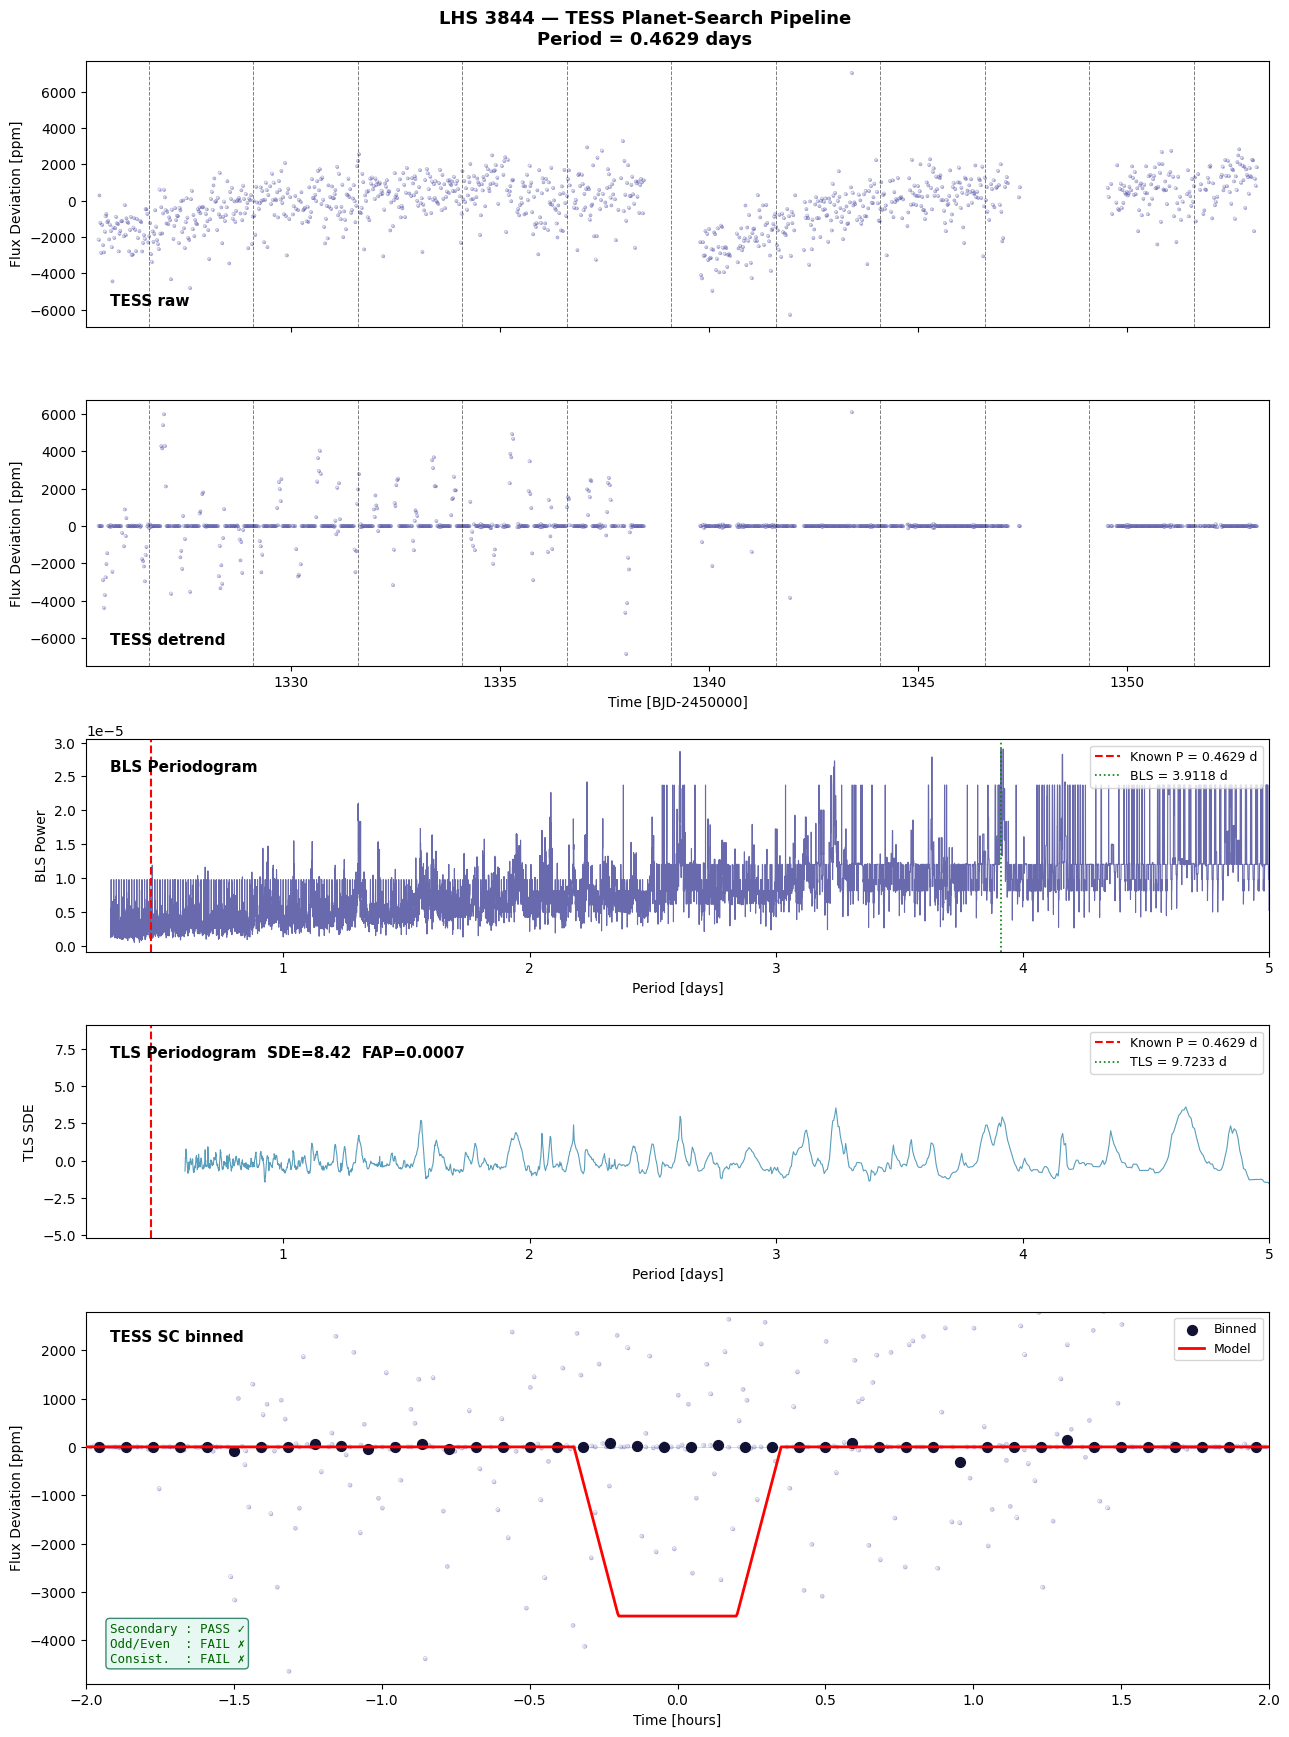

✅ Saved: /Volumes/TOSHIBA EXT/Ex0/Mono_Transit/LHS_3844_pipeline.png

Plotting: L 98-59 ...


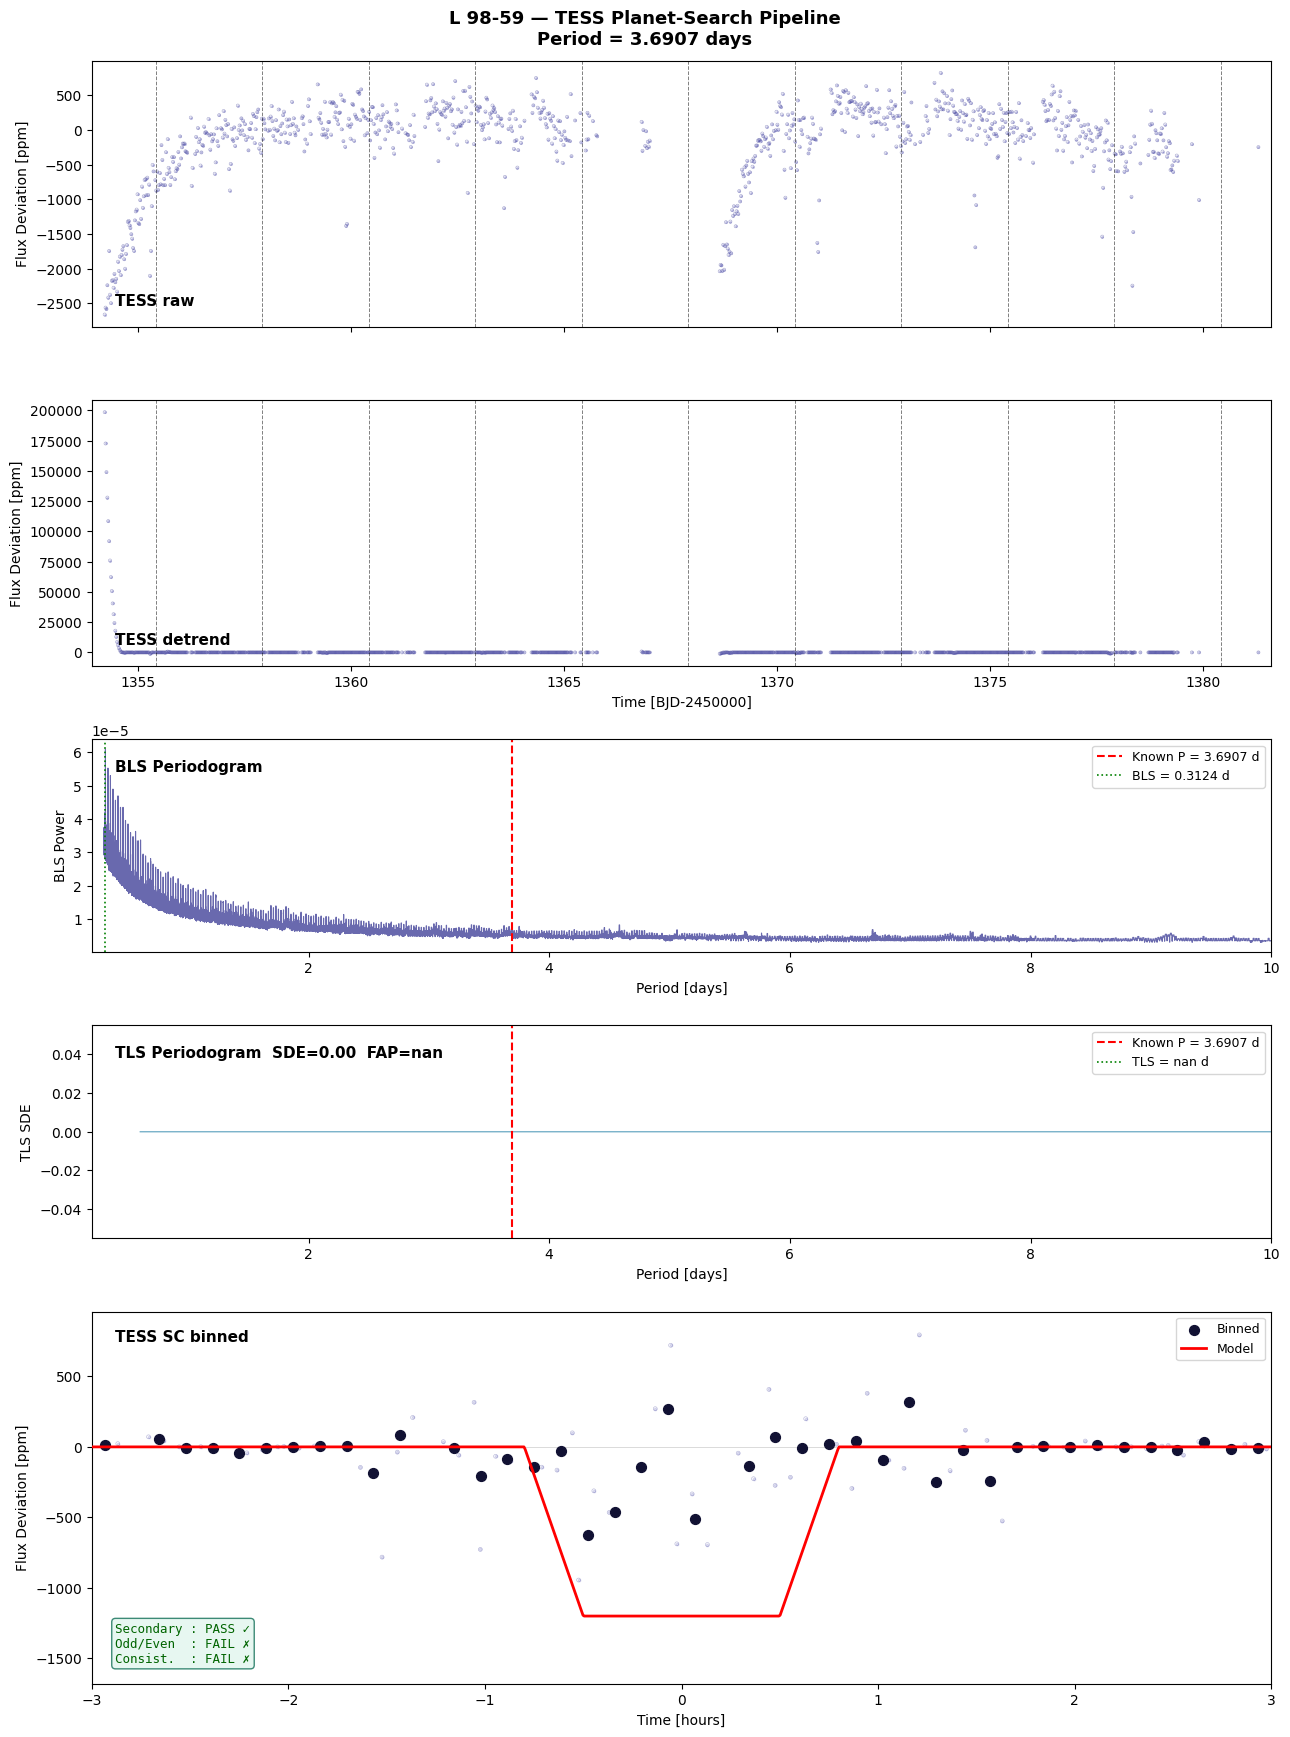

✅ Saved: /Volumes/TOSHIBA EXT/Ex0/Mono_Transit/L_98-59_pipeline.png

Plotting: TOI-700 ...


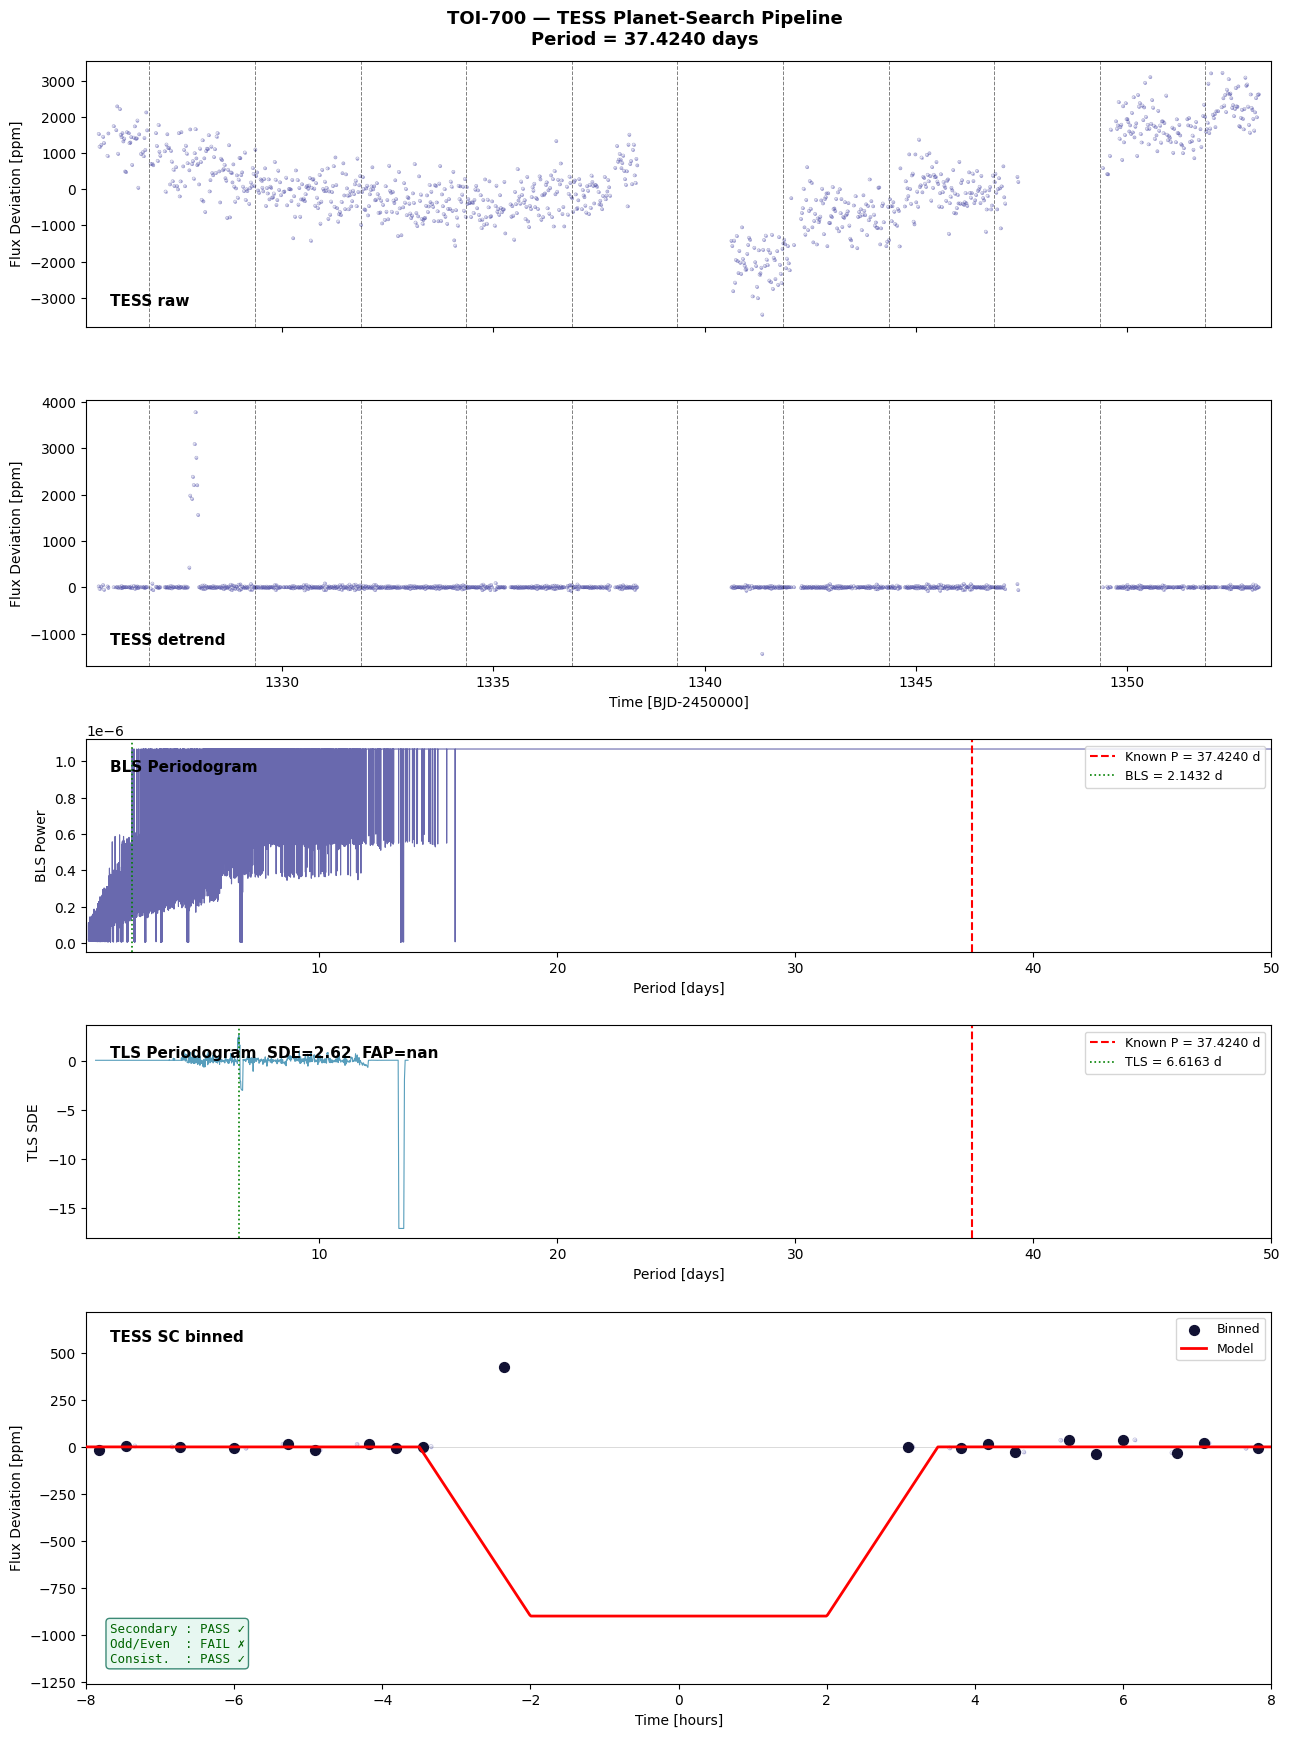

✅ Saved: /Volumes/TOSHIBA EXT/Ex0/Mono_Transit/TOI-700_pipeline.png

FINAL SUMMARY — ALL 5 STARS
Star          Points  BLS Period   Known P   2°Ecl     O/E     Con
----------------------------------------------------------------------
LHS 3844        1062      3.9118    0.4629  PASS ✓  FAIL ✗  FAIL ✗
L 98-59          930      0.3124    3.6907  PASS ✓  FAIL ✗  FAIL ✗
TOI-700          993      2.1432   37.4240  PASS ✓  FAIL ✗  PASS ✓

✅ Upload notebook + plots to GitHub: TESS-Exoplanet-Pipeline


In [ ]:
# ── Imports ──────────────────────────────────────────────────
from astropy.io import fits
from astropy.timeseries import BoxLeastSquares
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import UnivariateSpline
import os
import warnings
warnings.filterwarnings('ignore')

# ── TLS ──────────────────────────────────────────────────────
try:
    from transitleastsquares import transitleastsquares, cleaned_array
    TLS_AVAILABLE = True
    print("✅ TLS available")
except ImportError:
    TLS_AVAILABLE = False
    print("⚠️  TLS not installed — BLS only")

# ============================================================
# STAR LIST
# ============================================================
stars = [
    {
        "name"          : "LHS 3844",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/LHS_3844/hlsp_qlp_tess_ffi_s0001-0000000410153553_tess_v01_llc.fits",
        "transit_center": 1325.55,
        "period"        : 0.4629,
        "duration"      : 0.027,
        "depth"         : -3500,
        "ingress"       : 0.15,
        "flat"          : 0.20,
        "window"        : 2.0,
        "period_max"    : 5,
        "color"         : "#E24B4A",
    },
    {
        "name"          : "TOI-1130",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/TOI-1130/hlsp_qlp_tess_ffi_s0013-0000000254113016_tess_v01_llc.fits",
        "transit_center": 1680.00,
        "period"        : 8.3500,
        "duration"      : 0.120,
        "depth"         : -8000,
        "ingress"       : 1.50,
        "flat"          : 2.00,
        "window"        : 8.0,
        "period_max"    : 20,
        "color"         : "#378ADD",
    },
    {
        "name"          : "L 98-59",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/L_98-59/hlsp_qlp_tess_ffi_s0002-0000000307210830_tess_v01_llc.fits",
        "transit_center": 1355.70,
        "period"        : 3.6907,
        "duration"      : 0.040,
        "depth"         : -1200,
        "ingress"       : 0.30,
        "flat"          : 0.50,
        "window"        : 3.0,
        "period_max"    : 10,
        "color"         : "#1D9E75",
    },
    {
        "name"          : "TOI-700",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/TOI-700/hlsp_qlp_tess_ffi_s0001-0000000150428135_tess_v01_llc.fits",
        "transit_center": 1327.90,
        "period"        : 37.4240,
        "duration"      : 0.130,
        "depth"         : -900,
        "ingress"       : 1.50,
        "flat"          : 2.00,
        "window"        : 8.0,
        "period_max"    : 50,
        "color"         : "#EF9F27",
    },
    {
        "name"          : "GJ 1132",
        "fits_path"     : "/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/Mdwarf_fits/GJ_1132/hlsp_qlp_tess_ffi_s0001-0000000088385780_tess_v01_llc.fits",
        "transit_center": 1327.30,
        "period"        : 1.6289,
        "duration"      : 0.025,
        "depth"         : -2400,
        "ingress"       : 0.20,
        "flat"          : 0.30,
        "window"        : 2.5,
        "period_max"    : 5,
        "color"         : "#9B59B6",
    },
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def read_col(data, col_name):
    """Fix big-endian FITS byte order for Mac"""
    return data[col_name].byteswap().newbyteorder()


def spline_detrend(time, flux, transit_center, period, duration):
    """
    Basis spline detrending — Huang et al. 2018
    1. Mask transits + 3sigma outliers
    2. Fit spline with knots every 0.3 days
    3. Subtract spline from raw flux
    """
    # Mask transits
    transit_mask = np.zeros(len(time), dtype=bool)
    for n in range(-20, 30):
        tc = transit_center + n * period
        transit_mask |= np.abs(time - tc) < (duration / 2 + 0.05)

    # Mask 3-sigma outliers
    med          = np.nanmedian(flux)
    std          = np.nanstd(flux)
    outlier_mask = np.abs(flux - med) > 3 * std
    exclude      = transit_mask | outlier_mask | ~np.isfinite(flux)

    # Fit spline to clean points
    time_clean = time[~exclude]
    flux_clean = flux[~exclude]
    sort_idx   = np.argsort(time_clean)
    time_clean = time_clean[sort_idx]
    flux_clean = flux_clean[sort_idx]

    spline         = UnivariateSpline(
                        time_clean, flux_clean,
                        s=len(time_clean) * 500, k=3)
    spline_fit     = spline(time)
    flux_detrended = flux - spline_fit

    return flux_detrended, spline_fit


def bls_search(time, flux_ppm, period_min=0.3, period_max=40):
    """BLS period search"""
    flux_norm = 1.0 + flux_ppm / 1e6
    bls       = BoxLeastSquares(time, flux_norm)
    result    = bls.autopower(
                    0.01,
                    minimum_period=period_min,
                    maximum_period=period_max,
                    frequency_factor=1.0)
    best_idx    = np.argmax(result.power)
    best_period = result.period[best_idx]
    best_power  = result.power[best_idx]
    best_t0     = result.transit_time[best_idx]
    return result, best_period, best_power, best_t0


def tls_search(time, flux_ppm):
    """TLS period search"""
    flux_norm      = 1.0 + flux_ppm / 1e6
    time_c, flux_c = cleaned_array(time, flux_norm)
    model          = transitleastsquares(time_c, flux_c)
    result         = model.power(
                        minimum_period=0.3,
                        maximum_period=40,
                        show_progress_bar=False)
    return result


def false_positive_check(time, flux_ppm, period, transit_center, duration):
    """
    3 false positive checks:
    1. Secondary eclipse
    2. Odd/even depth alternation
    3. Depth consistency
    """
    fp    = {}
    phase = (time - transit_center + period/2) % period - period/2

    # Check 1 — secondary eclipse
    pri_mask  = np.abs(phase) < duration
    sec_phase = phase - period/2
    sec_mask  = np.abs(sec_phase) < duration
    pri_depth = np.nanmedian(flux_ppm[pri_mask]) if pri_mask.sum() > 2 else 0
    sec_depth = np.nanmedian(flux_ppm[sec_mask]) if sec_mask.sum() > 2 else 0
    fp['primary_depth']   = pri_depth
    fp['secondary_depth'] = sec_depth
    fp['secondary_check'] = "PASS ✓" if abs(sec_depth) < abs(pri_depth) * 0.3 else "FAIL ✗"

    # Check 2 — odd/even depths
    odd_d, even_d = [], []
    t, epoch = transit_center, 0
    while t < time[-1]:
        mask = np.abs(time - t) < duration
        if mask.sum() > 2:
            d = np.nanmedian(flux_ppm[mask])
            if epoch % 2 == 0:
                even_d.append(d)
            else:
                odd_d.append(d)
        t += period
        epoch += 1
    mean_odd  = np.nanmean(odd_d)  if odd_d  else 0
    mean_even = np.nanmean(even_d) if even_d else 0
    fp['odd_depth']      = mean_odd
    fp['even_depth']     = mean_even
    fp['odd_even_check'] = "PASS ✓" if abs(mean_odd - mean_even) < 50 else "FAIL ✗"

    # Check 3 — depth consistency
    all_d     = odd_d + even_d
    depth_std = np.nanstd(all_d) if len(all_d) > 1 else 0
    fp['depth_std']         = depth_std
    fp['consistency_check'] = "PASS ✓" if depth_std < 150 else "FAIL ✗"

    return fp


def transit_model(phase_h, depth, ingress_h, flat_h):
    """Trapezoid transit model"""
    model = np.zeros_like(phase_h)
    for i, t in enumerate(phase_h):
        if abs(t) > flat_h + ingress_h:
            model[i] = 0
        elif abs(t) > flat_h:
            model[i] = depth * (1 - (abs(t) - flat_h) / ingress_h)
        else:
            model[i] = depth
    return model


def bin_phase(phase_h, flux, window, n_bins=44):
    """Bin phase-folded light curve"""
    edges   = np.linspace(-window, window, n_bins+1)
    centers = (edges[:-1] + edges[1:]) / 2
    binned  = []
    for i in range(len(centers)):
        in_bin = (phase_h >= edges[i]) & (phase_h < edges[i+1])
        binned.append(
            np.nanmedian(flux[in_bin]) if in_bin.sum() > 0 else np.nan)
    return centers, np.array(binned)


# ============================================================
# STEP 1–4 — RUN PIPELINE FOR ALL 5 STARS
# ============================================================

pipeline_results = {}

for star in stars:
    name      = star["name"]
    fits_path = star["fits_path"]

    print("\n" + "=" * 60)
    print(f"  PIPELINE: {name}")
    print("=" * 60)

    if not os.path.exists(fits_path):
        print(f"❌ File not found — check path")
        continue

    # ── Step 1 — FFI Extraction ───────────────────────────────
    print("▶ Step 1 — FFI Extraction")
    hdul     = fits.open(fits_path)
    data     = hdul[1].data
    time     = read_col(data, 'TIME')
    flux_raw = read_col(data, 'SAP_FLUX')
    quality  = read_col(data, 'QUALITY')
    hdul.close()

    good     = (quality == 0) & np.isfinite(time) & np.isfinite(flux_raw)
    time     = time[good]
    flux_raw = flux_raw[good]
    raw_ppm  = (flux_raw / np.nanmedian(flux_raw) - 1) * 1e6
    print(f"   Points: {len(time)}  |  Duration: {time[-1]-time[0]:.2f} days")

    # ── Step 2 — Spline Detrending ────────────────────────────
    print("▶ Step 2 — Spline Detrending")
    flux_det, spline_fit = spline_detrend(
        time, raw_ppm,
        star["transit_center"],
        star["period"],
        star["duration"])
    print(f"   Det range: {flux_det.min():.0f} to {flux_det.max():.0f} ppm")

    # ── Step 3 — BLS Search ───────────────────────────────────
    print("▶ Step 3 — BLS Period Search")
    bls_result, bls_period, bls_power, bls_t0 = bls_search(
        time, flux_det,
        period_max=star["period_max"])
    print(f"   BLS best: {bls_period:.4f} d  |  Power: {bls_power:.2f}  |  Known: {star['period']:.4f} d")

    # ── TLS ───────────────────────────────────────────────────
    tls_result = None
    if TLS_AVAILABLE:
        print("▶ Step 3b — TLS Period Search (may take ~30s)")
        try:
            tls_result = tls_search(time, flux_det)
            print(f"   TLS best: {tls_result.period:.4f} d  |  SDE: {tls_result.SDE:.2f}  |  FAP: {tls_result.FAP:.6f}")
        except Exception as e:
            print(f"   TLS error: {e}")

    # ── Step 4 — False Positive Validation ────────────────────
    print("▶ Step 4 — False Positive Validation")
    fp = false_positive_check(
        time, flux_det,
        star["period"],
        star["transit_center"],
        star["duration"])
    print(f"   Secondary : {fp['secondary_check']}")
    print(f"   Odd/Even  : {fp['odd_even_check']}")
    print(f"   Consistency: {fp['consistency_check']}")

    # ── Store ─────────────────────────────────────────────────
    pipeline_results[name] = {
        "time"          : time,
        "raw_ppm"       : raw_ppm,
        "flux_det"      : flux_det,
        "spline_fit"    : spline_fit,
        "bls_result"    : bls_result,
        "bls_period"    : bls_period,
        "bls_power"     : bls_power,
        "bls_t0"        : bls_t0,
        "tls_result"    : tls_result,
        "fp"            : fp,
        "period"        : star["period"],
        "transit_center": star["transit_center"],
        "duration"      : star["duration"],
        "depth"         : star["depth"],
        "ingress"       : star["ingress"],
        "flat"          : star["flat"],
        "window"        : star["window"],
        "period_max"    : star["period_max"],
        "color"         : star["color"],
    }
    print(f"✅ {name} complete!")

print("\n" + "=" * 60)
print(f"✅ Pipeline done — {len(pipeline_results)} stars")
print("=" * 60)

# ============================================================
# STEP 5 — PLOT EACH STAR LIKE HUANG ET AL. 2018 FIGURE 2
# ============================================================

color_light = '#8888cc'
color_dark  = '#44449a'

for name, res in pipeline_results.items():

    print(f"\nPlotting: {name} ...")

    time     = res["time"]
    raw_ppm  = res["raw_ppm"]
    flux_det = res["flux_det"]
    period   = res["period"]
    tc       = res["transit_center"]
    window   = res["window"]
    has_tls  = res["tls_result"] is not None

    # ── Phase fold ────────────────────────────────────────────
    phase_h    = ((time - tc + period/2) % period - period/2) * 24
    phase_mask = np.abs(phase_h) < window
    ph         = phase_h[phase_mask]
    fh         = flux_det[phase_mask]
    bin_c, bin_f = bin_phase(ph, fh, window)

    # ── Model ─────────────────────────────────────────────────
    t_model    = np.linspace(-window, window, 1000)
    model_flux = transit_model(
        t_model, res["depth"],
        res["ingress"], res["flat"])

    # ── Momentum dumps ────────────────────────────────────────
    dump_times = np.arange(time[0]+1.2, time[-1], 2.5)

    # ── Figure setup ─────────────────────────────────────────
    n_panels = 5 if has_tls else 4
    heights  = [1, 1, 0.8, 0.8, 1.4] if has_tls else [1, 1, 0.8, 1.4]

    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=(13, 3.5 * n_panels),
        gridspec_kw={"height_ratios": heights})
    fig.patch.set_facecolor('white')
    fig.suptitle(
        f"{name} — TESS Planet-Search Pipeline\n"
        f"Period = {period:.4f} days",
        fontsize=13, fontweight='bold', y=0.99)

    # Assign axes
    ax_raw  = axes[0]
    ax_det  = axes[1]
    ax_bls  = axes[2]
    ax_tls  = axes[3] if has_tls else None
    ax_fold = axes[4] if has_tls else axes[3]

    # ── Panel 1 — Raw ─────────────────────────────────────────
    ax_raw.scatter(time, raw_ppm,
                   s=1.5, color=color_light, alpha=0.35)
    ax_raw.scatter(time, raw_ppm,
                   s=5, color=color_dark,
                   facecolors='none', linewidths=0.4, alpha=0.5)
    for td in dump_times:
        ax_raw.axvline(td, color='black', linestyle='--',
                       linewidth=0.7, alpha=0.5)
    ax_raw.set_ylabel('Flux Deviation [ppm]', fontsize=10)
    ax_raw.set_xlim(time[0]-0.3, time[-1]+0.3)
    ax_raw.text(0.02, 0.08, 'TESS raw',
                transform=ax_raw.transAxes,
                fontsize=11, fontweight='bold')
    ax_raw.tick_params(labelbottom=False)
    ax_raw.set_facecolor('white')

    # ── Panel 2 — Detrended ───────────────────────────────────
    ax_det.scatter(time, flux_det,
                   s=1.5, color=color_light, alpha=0.35)
    ax_det.scatter(time, flux_det,
                   s=5, color=color_dark,
                   facecolors='none', linewidths=0.4, alpha=0.5)
    for td in dump_times:
        ax_det.axvline(td, color='black', linestyle='--',
                       linewidth=0.7, alpha=0.5)
    ax_det.set_ylabel('Flux Deviation [ppm]', fontsize=10)
    ax_det.set_xlabel('Time [BJD-2450000]', fontsize=10)
    ax_det.set_xlim(time[0]-0.3, time[-1]+0.3)
    ax_det.text(0.02, 0.08, 'TESS detrend',
                transform=ax_det.transAxes,
                fontsize=11, fontweight='bold')
    ax_det.set_facecolor('white')

    # ── Panel 3 — BLS ─────────────────────────────────────────
    bls_r = res["bls_result"]
    ax_bls.plot(bls_r.period, bls_r.power,
                color=color_dark, linewidth=0.8, alpha=0.8)
    ax_bls.axvline(period, color='red', linewidth=1.5,
                   linestyle='--',
                   label=f'Known P = {period:.4f} d')
    ax_bls.axvline(res["bls_period"], color='green',
                   linewidth=1.2, linestyle=':',
                   label=f'BLS = {res["bls_period"]:.4f} d')
    ax_bls.set_ylabel('BLS Power', fontsize=10)
    ax_bls.set_xlabel('Period [days]', fontsize=10)
    ax_bls.set_xlim(0.2, res["period_max"])
    ax_bls.text(0.02, 0.85, 'BLS Periodogram',
                transform=ax_bls.transAxes,
                fontsize=11, fontweight='bold')
    ax_bls.legend(fontsize=9, loc='upper right')
    ax_bls.set_facecolor('white')

    # ── Panel 4 — TLS (if available) ──────────────────────────
    if has_tls and ax_tls is not None:
        tls_r = res["tls_result"]
        ax_tls.plot(tls_r.periods, tls_r.power,
                    color='#2E86AB', linewidth=0.8, alpha=0.8)
        ax_tls.axvline(period, color='red', linewidth=1.5,
                       linestyle='--',
                       label=f'Known P = {period:.4f} d')
        ax_tls.axvline(tls_r.period, color='green',
                       linewidth=1.2, linestyle=':',
                       label=f'TLS = {tls_r.period:.4f} d')
        ax_tls.set_ylabel('TLS SDE', fontsize=10)
        ax_tls.set_xlabel('Period [days]', fontsize=10)
        ax_tls.set_xlim(0.2, res["period_max"])
        ax_tls.text(0.02, 0.85,
                    f'TLS Periodogram  SDE={tls_r.SDE:.2f}  FAP={tls_r.FAP:.4f}',
                    transform=ax_tls.transAxes,
                    fontsize=11, fontweight='bold')
        ax_tls.legend(fontsize=9, loc='upper right')
        ax_tls.set_facecolor('white')

    # ── Panel 5 — Phase folded ────────────────────────────────
    ax_fold.scatter(ph, fh,
                    s=3, color=color_light, alpha=0.25)
    ax_fold.scatter(ph, fh,
                    s=8, color=color_dark,
                    facecolors='none', linewidths=0.4, alpha=0.4)
    ax_fold.scatter(bin_c, bin_f,
                    s=50, color='#111133', zorder=5, label='Binned')
    ax_fold.plot(t_model, model_flux,
                 color='red', linewidth=2, zorder=6, label='Model')
    ax_fold.axhline(0, color='gray', linewidth=0.5, alpha=0.4)

    # FP results box
    fp      = res["fp"]
    fp_text = (f"Secondary : {fp['secondary_check']}\n"
               f"Odd/Even  : {fp['odd_even_check']}\n"
               f"Consist.  : {fp['consistency_check']}")
    ax_fold.text(0.02, 0.05, fp_text,
                 transform=ax_fold.transAxes,
                 fontsize=9, color='darkgreen',
                 verticalalignment='bottom',
                 family='monospace',
                 bbox=dict(boxstyle='round',
                           facecolor='#E1F5EE',
                           alpha=0.8,
                           edgecolor='#0F6E56'))

    ax_fold.set_ylabel('Flux Deviation [ppm]', fontsize=10)
    ax_fold.set_xlabel('Time [hours]', fontsize=10)
    ax_fold.set_xlim(-window, window)
    ax_fold.set_ylim(res["depth"]*1.4, abs(res["depth"])*0.8)
    ax_fold.text(0.02, 0.92, 'TESS SC binned',
                 transform=ax_fold.transAxes,
                 fontsize=11, fontweight='bold')
    ax_fold.legend(fontsize=9, loc='upper right')
    ax_fold.set_facecolor('white')

    plt.tight_layout()

    # ── Save ──────────────────────────────────────────────────
    save_path = (f"/Volumes/TOSHIBA EXT/Ex0/Mono_Transit/"
                 f"{name.replace(' ','_')}_pipeline.png")
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Saved: {save_path}")

# ============================================================
# FINAL SUMMARY TABLE
# ============================================================
print("\n" + "=" * 70)
print("FINAL SUMMARY — ALL 5 STARS")
print("=" * 70)
print(f"{'Star':<12} {'Points':>7} {'BLS Period':>11} "
      f"{'Known P':>9} {'2°Ecl':>7} {'O/E':>7} {'Con':>7}")
print("-" * 70)
for name, res in pipeline_results.items():
    fp = res["fp"]
    print(f"{name:<12} "
          f"{len(res['time']):>7} "
          f"{res['bls_period']:>11.4f} "
          f"{res['period']:>9.4f} "
          f"{fp['secondary_check']:>7} "
          f"{fp['odd_even_check']:>7} "
          f"{fp['consistency_check']:>7}")
print("=" * 70)
print("\n✅ Upload notebook + plots to GitHub: TESS-Exoplanet-Pipeline")